In [ ]:
!wget https://www.lamsade.dauphine.fr/~cazenave/project2025.zip
!unzip project2025.zip
!ls -l

!pip uninstall -y tensorflow
!pip install tensorrt-bindings==8.6.1
!pip install --extra-index-url https://pypi.nvidia.com tensorrt-libs
!pip install tensorflow[and-cuda]==2.15.0

!pip install pydot
!apt-get install -y graphviz

# redemarrer la session

--2025-04-07 16:21:43--  https://www.lamsade.dauphine.fr/~cazenave/project2025.zip
Resolving www.lamsade.dauphine.fr (www.lamsade.dauphine.fr)... 193.48.71.250
Connecting to www.lamsade.dauphine.fr (www.lamsade.dauphine.fr)|193.48.71.250|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 486727746 (464M) [application/zip]
Saving to: ‘project2025.zip’

project2025.zip     100%[===================>] 464.18M  71.3MB/s    in 6.6s    

2025-04-07 16:21:50 (69.9 MB/s) - ‘project2025.zip’ saved [486727746/486727746]

Archive:  project2025.zip
  inflating: games2022.data          
  inflating: Golois.cpython-310-x86_64-linux-gnu.so  
  inflating: Golois.cpython-38-x86_64-linux-gnu.so  
  inflating: golois.cpython-310-x86_64-linux-gnu.so  
  inflating: golois.cpython-311-x86_64-linux-gnu.so  
  inflating: golois.cpython-37m-x86_64-linux-gnu.so  
  inflating: golois.cpython-38-x86_64-linux-gnu.so  
  inflating: trainGolois.py          
total 2382012
-rw-r--r-- 1 root root 

In [ ]:
# Import Libraries

import gc
import sys
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np
import matplotlib.pyplot as plt

import golois

print ("Python version", sys.version_info)
print ("Tensorflow version", tf.__version__)


Python version sys.version_info(major=3, minor=11, micro=11, releaselevel='final', serial=0)
Tensorflow version 2.15.0


In [ ]:
# Configuration

planes = 31
moves = 361
N = 10000


input_data = np.random.randint(2, size=(N, 19, 19, planes))
input_data = input_data.astype ('float32')

policy = np.random.randint(moves, size=(N,))
policy = keras.utils.to_categorical (policy)

value = np.random.randint(2, size=(N,))
value = value.astype ('float32')

end = np.random.randint(2, size=(N, 19, 19, 2))
end = end.astype ('float32')

groups = np.zeros((N, 19, 19, 1))
groups = groups.astype ('float32')

In [ ]:
# Get Validation Data

print ("getValidation", flush = True)
golois.getValidation (input_data, policy, value, end)

getValidation


In [ ]:
#from tensorflow.keras.utils import plot_model
#from IPython.display import Image

from tensorflow import keras
from keras import regularizers
from keras.models import Model
from keras.layers import (
    Input, Dense, Conv2D, GlobalAveragePooling2D, Dropout, Flatten,
    Activation, BatchNormalization, Add, Reshape, DepthwiseConv2D, LeakyReLU,
    Multiply
)
from keras.utils import plot_model

def _se_block(input_tensor, filters, ratio=16, activation='relu'):
    se = GlobalAveragePooling2D()(input_tensor)
    se = Reshape((1, 1, filters))(se)
    se = Dense(filters // ratio, activation=activation, use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', use_bias=False)(se)
    return Multiply()([input_tensor, se])

def _conv_block(inputs, filters, kernel, activation='relu'):
    x = Conv2D(filters, kernel, padding='same', kernel_regularizer=regularizers.l2(0.0001), use_bias=False)(inputs)
    x = BatchNormalization(axis=1)(x)
    x = Activation(activation)(x)
    return x

def _bottleneck_block(inputs, filters, kernel, factor, se, activation='relu'):
    expanded_filters = filters * factor

    x = _conv_block(inputs, filters=expanded_filters, kernel=(1, 1), activation=activation)
    x = DepthwiseConv2D(kernel, padding='same', kernel_regularizer=regularizers.l2(0.0001), use_bias=False)(x)
    x = BatchNormalization(axis=1)(x)
    x = _conv_block(x, filters=filters, kernel=(1, 1), activation=activation)

    if se:
        x = _se_block(x, filters, 16, activation)

    x = Add()([x, inputs])
    x = Activation(activation)(x)
    return x

def GoMobileNetv2(input_shape, filters, factor, block_num, se, activation='relu'):
    inputs = Input(shape=input_shape)
    x = _conv_block(inputs, filters, (1, 1), activation=activation)

    for i in range(block_num):
        x = _bottleneck_block(x, filters, (3, 3), factor, se, activation=activation)

    policy_head = _conv_block(x, filters=1, kernel=(1, 1), activation=activation)
    policy_head = Flatten()(policy_head)
    policy_head = Activation('softmax', name='policy')(policy_head)

    value_head = GlobalAveragePooling2D()(x)
    value_head = Dense(50, kernel_regularizer=regularizers.l2(0.0001))(value_head)
    value_head = Activation(activation)(value_head)
    value_head = Dropout(0.3)(value_head)
    value_head = Dense(1, activation='sigmoid', name='value',
                       kernel_regularizer=regularizers.l2(0.0001))(value_head)

    model = keras.Model(inputs=inputs, outputs=[policy_head, value_head])
    return model

def GoMobileNetv3(input_shape, factor, se):

    inputs = Input(shape=input_shape)
    x = _conv_block(inputs, 32, (1, 1))

    x = _conv_block(x, filters=16, kernel=(1, 1))
    x = _bottleneck_block(x, 16, (3,3), factor, se)

    x = _conv_block(x, filters=32, kernel=(1, 1))
    x = _bottleneck_block(x, 32, (3,3), factor, se)

    x = _conv_block(x, filters=96, kernel=(1, 1))
    x = _bottleneck_block(x, 96, (3,3), factor, se)

    # Policy head
    policy_head = _conv_block(x, filters=1, kernel=(1, 1))
    policy_head = Flatten()(policy_head)
    policy_head = Activation('softmax', name='policy')(policy_head)

    # Value head
    value_head = GlobalAveragePooling2D()(x)
    value_head = Dense(50, kernel_regularizer=regularizers.l2(0.0001))(value_head)
    value_head = LeakyReLU()(value_head)
    value_head = Dropout(0.3)(value_head)
    value_head = Dense(1, activation='sigmoid', name='value',
                              kernel_regularizer=regularizers.l2(0.0001))(value_head)

    model = keras.Model(inputs=inputs, outputs=[policy_head, value_head])
    return model

def GoMobileNetv4(input_shape, factor, se):

    inputs = Input(shape=input_shape)
    x = _conv_block(inputs, 32, (1, 1))

    x = _conv_block(x, filters=16, kernel=(1, 1))
    x = _bottleneck_block(x, 16, (3,3), factor, se)

    x = _conv_block(x, filters=32, kernel=(1, 1))
    x = _bottleneck_block(x, 32, (5,5), factor, se)

    x = _conv_block(x, filters=64, kernel=(1, 1))
    x = _bottleneck_block(x, 64, (7,7), factor, se)

    # Policy head
    policy_head = _conv_block(x, filters=1, kernel=(1, 1))
    policy_head = Flatten()(policy_head)
    policy_head = Activation('softmax', name='policy')(policy_head)

    # Value head
    value_head = GlobalAveragePooling2D()(x)
    value_head = Dense(50, kernel_regularizer=regularizers.l2(0.0001))(value_head)
    value_head = LeakyReLU()(value_head)
    value_head = Dropout(0.3)(value_head)
    value_head = Dense(1, activation='sigmoid', name='value',
                              kernel_regularizer=regularizers.l2(0.0001))(value_head)

    model = keras.Model(inputs=inputs, outputs=[policy_head, value_head])
    return model

#model = GoMobileNetv3((19,19,31), 4, True)
#odel.summary()


# Sauvegarde du schéma au format PNG
#plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)
# Affichage dans le notebook
#Image(filename='model.png')


In [ ]:
import time
import pandas as pd
from tensorflow.keras import optimizers, callbacks

# Epochs number
epochs = 50

# Cosine Annealing function
def get_cosine_annealing_lr(epoch, base_lr=0.0005, min_lr=0.0000005, total_epochs=epochs):
    cos_inner = np.pi * (epoch % total_epochs) / total_epochs
    lr = min_lr + 0.5 * (base_lr - min_lr) * (1 + np.cos(cos_inner))
    print(f"[Cosine Annealing] Epoch {epoch+1}/{total_epochs} - lr: {lr:.8f}")
    return lr

# Scheduler de learning rate (comme dans le papier)
def get_learning_rate(epoch):
    if epoch < (epochs/5)*2.5:
        return 0.0005
    elif epoch < (epochs/5)*3:
        return 0.00005
    elif epoch < (epochs/5)*4:
        return 0.000005
    else:
        return 0.0000005

def train_model(model, batch=32, scheduler_type="cosine"):
  # Démarrer le chrono
  start_time = time.time()

  # Optimiseur Adam avec taux d’apprentissage initial
  # 💡 Optimiseur : SGD avec momentum
  optimizer = optimizers.SGD(learning_rate=get_learning_rate(0), momentum=0.9, nesterov=True)

  # Poids des pertes
  policy_weight = 1.0
  value_weight = 4.0

  # Pour stocker les métriques de chaque epoch
  all_history = []

  # Compilation du modèle
  model.compile(optimizer=optimizer,
                loss={'policy': 'categorical_crossentropy', 'value': 'binary_crossentropy'},
                loss_weights={'policy': policy_weight, 'value': value_weight},
                metrics={'policy': 'categorical_accuracy', 'value': 'mse'})

  # Entraînement avec scheduler
  for i in range(1, epochs + 1):

      # Choix du scheduler
      if scheduler_type == "cosine":
          lr = get_cosine_annealing_lr(i)
      elif scheduler_type == "step":
          lr = get_learning_rate(i)
      else:
          raise ValueError(f"Scheduler type inconnu : {scheduler_type}")

      keras.backend.set_value(model.optimizer.learning_rate, lr)
      print('epoch ' + str(i)+ ', lr '+str(lr))

      # Mise à jour dynamique du batch
      golois.getBatch(input_data, policy, value, end, groups, i * N)

      history = model.fit(input_data,
                          {'policy': policy, 'value': value},
                          epochs=1,
                          batch_size=batch,
                          verbose=1)

      # Stocker l’historique
      metrics = {key: val[0] for key, val in history.history.items()}
      metrics['epoch'] = i
      all_history.append(metrics)

      if i % 5 == 0:
          gc.collect()

      #if i % 20 == 0:
      golois.getValidation(input_data, policy, value, end)
      val = model.evaluate(input_data,
                              [policy, value], verbose=0, batch_size=batch)

  total_time = time.time() - start_time
  return val, pd.DataFrame(all_history), total_time

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_result(history_dfs, labels, epochs=None):
    assert len(history_dfs) == len(labels)

    # Titre
    info = []
    title = f"Epochs: {epochs}"

    # Grille personnalisée : 2 lignes (3 en haut, 2 en bas)
    fig = plt.figure(figsize=(18, 8))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    gs = gridspec.GridSpec(2, 3)

    # --- Ligne 1 : 3 plots ---
    ax1 = fig.add_subplot(gs[0, 0])
    for df, label in zip(history_dfs, labels):
        ax1.plot(df['epoch'], df['loss'], label=f'{label} Total Loss')
    ax1.set_title('Total Loss par Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Total Loss')
    ax1.legend()

    ax2 = fig.add_subplot(gs[0, 1])
    for df, label in zip(history_dfs, labels):
        if 'policy_loss' in df.columns:
            ax2.plot(df['epoch'], df['policy_loss'], label=f'{label} Policy Loss')
    ax2.set_title('Policy Loss par Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Policy Loss')
    ax2.legend()

    ax3 = fig.add_subplot(gs[0, 2])
    for df, label in zip(history_dfs, labels):
        if 'value_loss' in df.columns:
            ax3.plot(df['epoch'], df['value_loss'], label=f'{label} Value Loss')
    ax3.set_title('Value Loss par Epoch')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Value Loss')
    ax3.legend()

    # --- Ligne 2 : 2 plots ---
    ax4 = fig.add_subplot(gs[1, 0])
    for df, label in zip(history_dfs, labels):
        if 'policy_categorical_accuracy' in df.columns:
            ax4.plot(df['epoch'], df['policy_categorical_accuracy'], label=label)
    ax4.set_title('Policy Accuracy par Epoch')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Categorical Accuracy')
    ax4.legend()

    ax5 = fig.add_subplot(gs[1, 1])
    for df, label in zip(history_dfs, labels):
        if 'value_mse' in df.columns:
            ax5.plot(df['epoch'], df['value_mse'], label=label)
    ax5.set_title('Value MSE par Epoch')
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('MSE')
    ax5.legend()

    # Libérer la dernière case vide de la 2e ligne
    fig.delaxes(fig.add_subplot(gs[1, 2]))  # case vide propre

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

def print_validation_results(model_results, epoch=epochs):
    """
    Affiche les résultats de validation pour une liste de modèles.

    Paramètres :
    - model_results : liste de tuples (model, val, label)
    - epoch : (optionnel) numéro d'epoch à afficher dans le titre
    """
    for model, val, label, time in model_results:
        metrics = dict(zip(model.metrics_names, val))
        title = f"📊 Validation Results for {label}"
        if epoch is not None:
            title += f" — Epoch {epoch}"
        print(f"\n{title}:")
        for name, value in metrics.items():
            print(f"  - {name:<30}: {value:.4f}")
        print(f"  - Time: {time:.4f}")

In [ ]:
# Test Bach size
from google.colab import drive

model_64_4_3 = GoMobileNetv2((19,19,31), 64, 4, 3,  True)
val_64_4_3_32, all_history_64_4_3_32, total_time_64_4_3_32 = train_model(model_64_4_3, batch=32)
model_64_4_3 = GoMobileNetv2((19,19,31), 64, 4, 3,  True)
val_64_4_3_64, all_history_64_4_3_64, total_time_64_4_3_64 = train_model(model_64_4_3, batch=64)
model_64_4_3 = GoMobileNetv2((19,19,31), 64, 4, 3,  True)
val_64_4_3_128, all_history_64_4_3_128, total_time_64_4_3_128 = train_model(model_64_4_3, batch=128)
model_64_4_3 = GoMobileNetv2((19,19,31), 64, 4, 3,  True)
val_64_4_3_512, all_history_64_4_3_512, total_time_64_4_3_512 = train_model(model_64_4_3, batch=512)
model_64_4_3 = GoMobileNetv2((19,19,31), 64, 4, 3,  True)
val_64_4_3_1024, all_history_64_4_3_1024, total_time_64_4_3_1024 = train_model(model_64_4_3, batch=1024)

# Affichage des résultats
results = [
    (model_64_4_3, val_64_4_3_32, "Nesterov (64,4,3) Batch 32", total_time_64_4_3_32),
    (model_64_4_3, val_64_4_3_64, "Nesterov (64,4,3) Batch 64", total_time_64_4_3_64),
    (model_64_4_3, val_64_4_3_128, "Nesterov (64,4,3) Batch 128", total_time_64_4_3_128),
    (model_64_4_3, val_64_4_3_512, "Nesterov (64,4,3) Batch 512", total_time_64_4_3_512),
    (model_64_4_3, val_64_4_3_1024, "Nesterov (64,4,3) Batch 124", total_time_64_4_3_1024)
]
print_validation_results(results)

# Affichage des courbes comparatives
plot_result(
    history_dfs=[all_history_64_4_3_32, all_history_64_4_3_64, all_history_64_4_3_128, all_history_64_4_3_512, all_history_64_4_3_1024],
    labels=["Nesterov (64,4,3) Batch 32", "Nesterov (64,4,3) Batch 64", "Nesterov (64,4,3) Batch 128", "Nesterov (64,4,3) Batch 512", "Nesterov (64,4,3) Batch 1024"],
    epochs=epochs
)

In [ ]:
# Test Avec ou Sans SE
from google.colab import drive

model_64_4_3 = GoMobileNetv2((19,19,31), 64, 4, 3,  False)
val_64_4_3, all_history_64_4_3, total_time_64_4_3 = train_model(model_64_4_3)

model_64_4_3_se = GoMobileNetv2((19,19,31), 64, 4, 3,  True)
val_64_4_3_se, all_history_64_4_3_se, total_time_64_4_3_se = train_model(model_64_4_3_se)

# Affichage des résultats
results = [
    (model_64_4_3, val_64_4_3, "Nesterov (64,4,3)", total_time_64_4_3),
    (model_64_4_3_se, val_64_4_3_se, "Nesterov (64,4,3) SE", total_time_64_4_3_se)
]
print_validation_results(results)

# Affichage des courbes comparatives
plot_result(
    history_dfs=[all_history_64_4_3, all_history_64_4_3_se],
    labels=["Nesterov (64,4,3)", "Nesterov (64,4,3) SE"],
    epochs=epochs
)

In [ ]:
#Test increasing nb filter in layers

model_2 = GoMobileNetv2((19,19,31), 64, 4, 3,  True)
val_2, all_history_2, total_time_2 = train_model(model_2)

model_3 = GoMobileNetv3((19,19,31), 4, True)
val_3, all_history_3, total_time_3 = train_model(model_3)

# Affichage des résultats
results = [
    (model_2, val_2, "Mobile Fixe Filters Nb", total_time_2),
    (model_3, val_3, "Mobile Mix Filters Nb", total_time_3)
]
print_validation_results(results)

# Affichage des courbes comparatives
plot_result(
    history_dfs=[all_history_2, all_history_3],
    labels=["Mobile Fixe Filters Nb", "Mobile MIX Filters Nb"],
    epochs=epochs
)

In [ ]:
#Test increasing filter size (3x3) (5x5) (7x7) in layers

#model_2 = GoMobileNetv2((19,19,31), 64, 4, 3,  True)
#al_2, all_history_2, total_time_2 = train_model(model_2)

model_4 = GoMobileNetv4((19,19,31), 4, True)
val_4, all_history_4, total_time_4 = train_model(model_4)

# Affichage des résultats
results = [
    (model_2, val_2, "Mobile Fixe Filter Size", total_time_2),
    (model_3, val_3, "Mobile Increase Filter Size", total_time_4)
]
print_validation_results(results)

# Affichage des courbes comparatives
plot_result(
    history_dfs=[all_history_2, all_history_4],
    labels=["Mobile Fixe Filter Size", "Mobile Increase Filter Size"],
    epochs=epochs
)


In [ ]:
#activations_to_test = ['relu', 'leaky_relu', 'swish', 'gelu', 'mish']
activations_to_test = ['leaky_relu', 'swish']

results = []
histories = []

for act_name in activations_to_test:
    model = GoMobileNetv2((19, 19, 31), filters=64, factor=4, block_num=3, se=True, activation=act_name)
    val_result, history_df, training_time = train_model(model)
    results.append((model, val_result, f"MobileNetv2 + {act_name}", training_time))
    histories.append(history_df)

# Affichage des résultats comparatifs
print_validation_results(results)

# Affichage des courbes d'apprentissage
labels = [label for (_, _, label, _) in results]
plot_result(
    history_dfs=histories,
    labels=labels,
    epochs=50
)

epoch 1, lr 0.0005
313/313 [==============================] - 13s 24ms/step - loss: 7.8769 - policy_loss: 5.0290 - value_loss: 0.6940 - policy_categorical_accuracy: 0.0707 - value_mse: 0.1201
epoch 2, lr 0.0005
313/313 [==============================] - 7s 23ms/step - loss: 6.9831 - policy_loss: 4.1492 - value_loss: 0.6905 - policy_categorical_accuracy: 0.1743 - value_mse: 0.1201
epoch 3, lr 0.0005
313/313 [==============================] - 9s 28ms/step - loss: 6.7360 - policy_loss: 3.9054 - value_loss: 0.6897 - policy_categorical_accuracy: 0.2044 - value_mse: 0.1193
epoch 4, lr 0.0005
313/313 [==============================] - 7s 24ms/step - loss: 6.6176 - policy_loss: 3.7915 - value_loss: 0.6886 - policy_categorical_accuracy: 0.2195 - value_mse: 0.1193
epoch 5, lr 0.0005
313/313 [==============================] - 8s 26ms/step - loss: 6.5272 - policy_loss: 3.6986 - value_loss: 0.6892 - policy_categorical_accuracy: 0.2303 - value_mse: 0.1196
epoch 6, lr 0.0005
313/313 [================

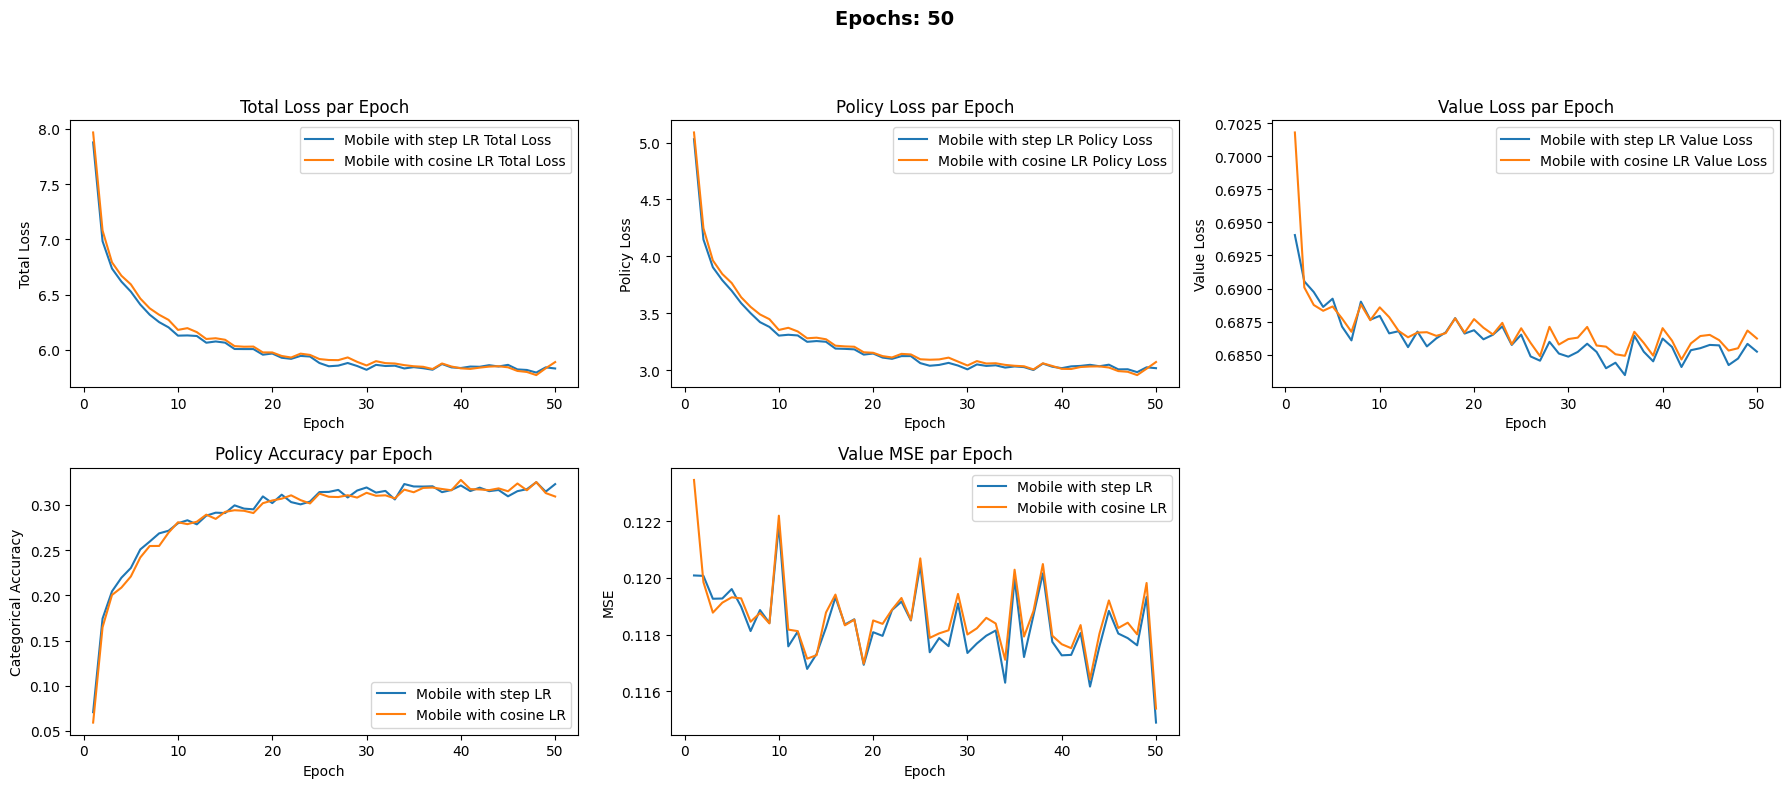

In [ ]:
#Test Step and Cosine

model_step = GoMobileNetv2((19,19,31), 64, 4, 3,  True)
val_step, all_history_step, total_time_step = train_model(model_step, scheduler_type="step")

model_cosine = GoMobileNetv2((19,19,31), 64, 4, 3,  True)
val_cosine,  all_history_cosine, total_time_cosine = train_model(model_cosine, scheduler_type="cosine")

# Affichage des résultats
results = [
    (model_step, val_step, "Mobile with step LR", total_time_step),
    (model_cosine, val_cosine, "Mobile with cosine LR", total_time_cosine)
]
print_validation_results(results)

# Affichage des courbes comparatives
plot_result(
    history_dfs=[all_history_step, all_history_cosine],
    labels=["Mobile with step LR", "Mobile with cosine LR"],
    epochs=epochs
)